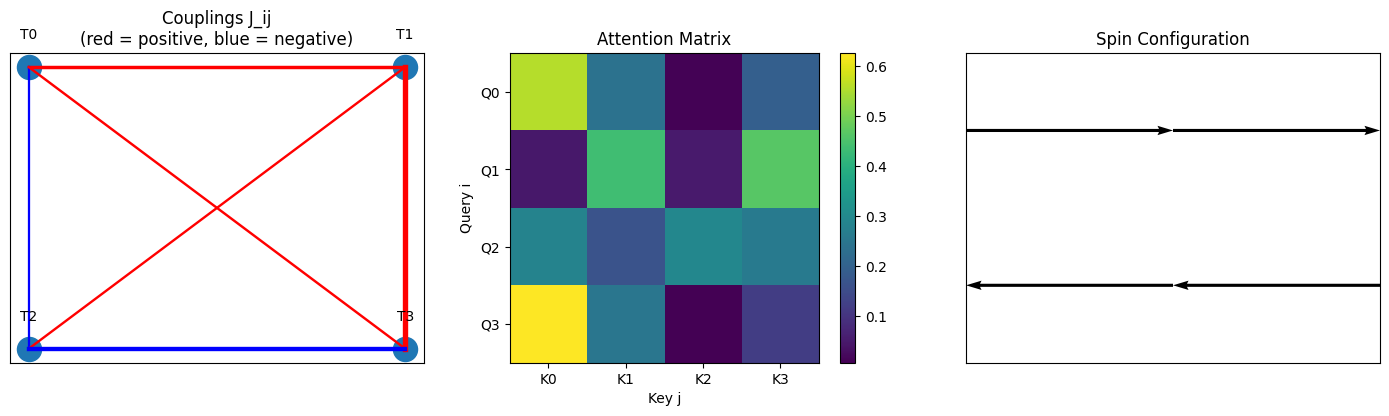

In [9]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

d = 3
Q = np.random.randn(4, d)
K = np.random.randn(4, d)

J = Q @ K.T
J_sym = (J + J.T) / 2

def softmax(x, axis=-1):
    e = np.exp(x - np.max(x, axis=axis, keepdims=True))
    return e / e.sum(axis=axis, keepdims=True)

attention = softmax(J, axis=1)

#spin config
spins = np.array([
    [1, 0],
    [1, 0],
    [-1, 0],
    [-1, 0]
])

# fixed 2D positions
pos = np.array([
    [0,1],
    [1,1],
    [0,0],
    [1,0]
])

# ---------------------------
# 3. Plot
# ---------------------------
fig = plt.figure(figsize=(14,4))

# Coupling graph (manual) 
plt.subplot(1,3,1)

for i in range(4):
    for j in range(i+1,4):
        weight = J_sym[i,j]
        linewidth = abs(weight) * 2
        color = 'red' if weight > 0 else 'blue'
        plt.plot([pos[i,0], pos[j,0]],
                 [pos[i,1], pos[j,1]],
                 linewidth=linewidth,
                 color=color)

plt.scatter(pos[:,0], pos[:,1], s=300)
for i in range(4):
    plt.text(pos[i,0], pos[i,1]+0.1, f"T{i}", ha='center')

plt.title("Couplings J_ij\n(red = positive, blue = negative)")
plt.xticks([])
plt.yticks([])

#heatmap
plt.subplot(1,3,2)
plt.imshow(attention, cmap='viridis')
plt.colorbar()
plt.xticks(range(4), [f"K{j}" for j in range(4)])
plt.yticks(range(4), [f"Q{i}" for i in range(4)])
plt.title("Attention Matrix")
plt.xlabel("Key j")
plt.ylabel("Query i")

# --- Spins ---
plt.subplot(1,3,3)
plt.quiver(pos[:,0] - spins[:,0]*0.5, pos[:,1] - spins[:,1]*0.5,
           spins[:,0], spins[:,1],
           angles='xy',
           scale_units='xy',
           scale=1)

plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)

plt.title("Spin Configuration")
plt.xticks([])
plt.yticks([])

plt.tight_layout()
plt.show()